In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [2]:

def load_embeddings(file_path):
    with open(file_path, "r") as f:
        data = json.load(f)

    # convert to numpy
    for k in data:
        data[k] = np.array(data[k])

    return data

topic_embeddings = load_embeddings("../data/embeddings/topic_embeddings.json")

ministry_embeddings = load_embeddings("../data/embeddings/ministry_embeddings3.json")

In [3]:
topics = list(topic_embeddings.keys())
ministries = list(ministry_embeddings.keys())

# -------------------------------
# STEP 1: Build similarity matrix
# -------------------------------
sim_matrix = {}

for t in topics:
    sim_matrix[t] = {}
    topic_vec = topic_embeddings[t].reshape(1, -1)

    for m in ministries:
        ministry_vecs = ministry_embeddings[m]  # (n_vectors, dim)

        scores = cosine_similarity(topic_vec, ministry_vecs)[0]

        # choose method
        # score = np.max(scores)        # OPTION 1
        score = np.mean(scores)     # OPTION 2
        # score = np.mean(np.sort(scores)[-5:])  # OPTION 3 (Top-5 mean)

        sim_matrix[t][m] = score

In [4]:
sim_matrix_df = pd.DataFrame(sim_matrix)

In [5]:
sim_matrix_df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Ministry_of_Power_MoP_,0.199828,0.080457,0.201847,0.165257,0.069361,0.213586,0.166058,0.047112,0.089662,0.167606,...,0.103779,0.116254,0.150230,0.101118,0.087839,0.060258,0.302493,0.137414,0.121836,0.029219
Ministry_of_Micro_Small_Medium_Enterprises_MoME_,0.274143,0.133572,0.286410,0.217281,0.113666,0.212043,0.209816,0.100023,0.065227,0.241830,...,0.122726,0.190767,0.209120,0.190787,0.147634,0.109061,0.179783,0.180646,0.314095,0.071981
Ministry_of_AYUSH_MoA_,0.090123,0.048656,0.275131,0.149616,0.099994,0.122171,0.092303,0.009040,0.040918,0.186462,...,0.068789,0.092238,0.108673,0.173052,0.065830,0.203800,0.072858,0.135939,0.118004,0.376202
Ministry_of_Textiles_MoT_,0.269330,0.135429,0.172746,0.114986,0.057564,0.163356,0.179646,0.142071,0.041474,0.151127,...,0.103806,0.113356,0.161331,0.150952,0.101886,0.122903,0.122116,0.128052,0.395242,0.091651
Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_,0.164328,0.117215,0.293203,0.176960,0.184611,0.278772,0.166845,0.043391,0.114280,0.194180,...,0.160875,0.183493,0.223016,0.218668,0.170475,0.061787,0.128244,0.274575,0.124469,0.103735
Ministry_of_Law_and_Justice_MoLJ_,0.114009,0.121919,0.209975,0.181424,0.398262,0.260234,0.154613,-0.016580,0.067053,0.255988,...,0.106976,0.178454,0.297889,0.180109,0.121416,0.054463,0.110092,0.230297,0.097930,0.042683
Ministry_of_Social_Justice_and_Empowerment_MoSJE_,0.114326,0.092040,0.287662,0.207433,0.202189,0.207835,0.122560,0.041190,0.074826,0.273743,...,0.101380,0.151299,0.197283,0.218142,0.196734,0.119169,0.111405,0.200423,0.115117,0.140429
Ministry_of_Culture,0.089660,0.101218,0.192844,0.197878,0.131905,0.168770,0.066627,0.077850,0.086467,0.189084,...,0.076651,0.085801,0.168888,0.156273,0.036348,0.220424,0.030357,0.171160,0.112956,0.084457
Ministry_of_Heavy_Industries_MoHI_,0.333230,0.109314,0.213057,0.159723,0.086329,0.215063,0.171570,0.094680,0.051921,0.185056,...,0.196690,0.169447,0.167847,0.156657,0.101078,0.079604,0.222243,0.185569,0.206984,0.060397
Ministry_of_Statistics_and_Programme_Implementation_MoSPI_,0.216288,0.100692,0.248345,0.160842,0.096953,0.370207,0.216130,0.043571,0.110746,0.199004,...,0.104227,0.093726,0.160713,0.160832,0.121962,0.068272,0.202773,0.184613,0.170903,0.079008


In [6]:

# save the max score
max_sim_score = sim_matrix_df.max(axis=1)

# for each ministry (row), find the topic with highest similarity
sim_matrix_df["Most Similar Topic"] = sim_matrix_df.idxmax(axis=1)

In [7]:
# print topic {id}: and ministries mapped to it
topic_to_ministries = {}
for topic in topics:
    topic_to_ministries[topic] = sim_matrix_df[sim_matrix_df["Most Similar Topic"] == topic].index.tolist()
    
for t in topic_to_ministries:
    print(f"\nTopic {t}:")
    for m in topic_to_ministries[t]:
        score = sim_matrix_df.loc[m, t]
        print("   ", m, f"({score*100:.2f}%)")


Topic 0:
    Ministry_of_Heavy_Industries_MoHI_ (33.32%)
    Ministry_of_Steel_MoS_ (31.70%)

Topic 1:
    Ministry_of_Information_and_Broadcasting_MIB_ (36.10%)

Topic 2:
    Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_ (29.32%)
    Ministry_of_Social_Justice_and_Empowerment_MoSJE_ (28.77%)
    Ministry_of_Tourism_MoT_ (20.72%)
    Ministry_of_Youth_Affairs_and_Sports_MoYAS_ (24.31%)
    Ministry_of_Health_and_Family_Welfare_MoHFW_ (30.28%)
    Ministry_of_Development_of_North_Eastern_Region_MDoNER_ (30.17%)
    Ministry_of_Finance_MoF_ (27.66%)

Topic 3:
    Ministry_of_Cooperation_MoC_ (36.65%)

Topic 4:
    Ministry_of_Law_and_Justice_MoLJ_ (39.83%)
    Ministry_of_Minority_Affairs_MoMA_ (25.50%)

Topic 5:
    Ministry_of_Statistics_and_Programme_Implementation_MoSPI_ (37.02%)
    Ministry_of_Planning_MoP_ (32.95%)
    Ministry_of_Parliamentary_Affairs_MPA_ (37.45%)

Topic 6:
    Ministry_of_Electronics_and_Information_Technology_MeitY_ (27.94%)
    Ministry_of_Com

In [8]:
# using max_sim_score, and sim_matrix_df["Most Similar Topic"], build a dataframe with columns: "Topic", "Most Similar Ministry", "Similarity Score"
topic_ministry_df = pd.DataFrame({
    "TopicID": sim_matrix_df["Most Similar Topic"],
    "Score": max_sim_score
})
topic_ministry_df      

,TopicID,Score
Ministry_of_Power_MoP_,21,0.302493
Ministry_of_Micro_Small_Medium_Enterprises_MoME_,23,0.314095
Ministry_of_AYUSH_MoA_,24,0.376202
Ministry_of_Textiles_MoT_,23,0.395242
Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_,2,0.293203
Ministry_of_Law_and_Justice_MoLJ_,4,0.398262
Ministry_of_Social_Justice_and_Empowerment_MoSJE_,2,0.287662
Ministry_of_Culture,11,0.237156
Ministry_of_Heavy_Industries_MoHI_,0,0.333230
Ministry_of_Statistics_and_Programme_Implementation_MoSPI_,5,0.370207


In [9]:
# reset index to get ministry as a column
topic_ministry_df = topic_ministry_df.reset_index().rename(columns={"index": "Ministry"})
topic_ministry_df[['TopicID', 'Ministry', 'Score']].to_csv("../data/topic_modeling/topic_ministry_mapping3_mean.csv", index=False)

In [10]:
# print if any ministry is mapped to multiple topics
ministry_count = {}
for ministry in ministries:
    ministry_count[ministry] = sim_matrix_df[sim_matrix_df["Most Similar Topic"] == ministry].shape[0]
    
for ministry, count in ministry_count.items():
    if count > 1:
        print(f"{ministry} is mapped to {count} topics")

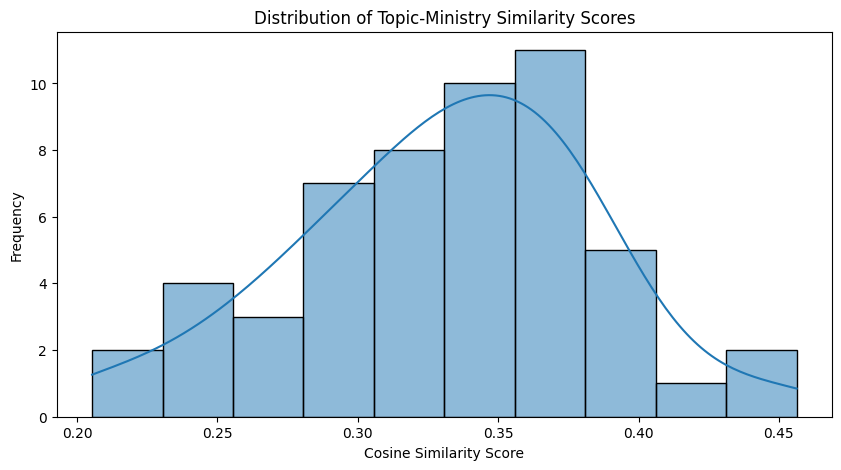

In [11]:
# plot score wise frequency distribution
plt.figure(figsize=(10,5))
sns.histplot(topic_ministry_df['Score'].values, bins=10, kde=True)
plt.title("Distribution of Topic-Ministry Similarity Scores")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Frequency")
plt.show()